In [1]:
from pathlib import Path
import os
import textwrap

import h5py
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq
import seaborn as sns
import circlify
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import (
    Circle,
    Ellipse,
    PathPatch,
    Rectangle,
)

DATA_STATISTICS_DIR = PROJECT_ROOT / '1. Database/2. Downstream/Data_statistics'
FIGURES_DIR = DATA_STATISTICS_DIR / 'figures'


/mnt/T40/lzh/conda/miniconda3/envs/cellcharter_tacco/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
organ_colors = [
    "#E6C58D",
    "#E5E0D4",
    "#D3B47A",
    "#F1BBBB",
    "#B5CDDE",
    "#DDC7D8",
    "#D8D29A",
    "#A9C0C7",
    "#F0D9B2",
    "#B8AFC0",
    "#E8C7CB",
    "#E8DDD9",
    "#D8D8D2",
    "#DED5F0"
]

In [3]:
tab20_colors = [
    '#8FAABD', '#D6E0E8', '#D8A77A', '#EBD1B5', '#8DBB8D',
    '#CBE1C6', '#C98C8C', '#E8C5C3', '#A094BF', '#DAD2E5',
    '#A68A82', '#DFC9C3', '#CD94B3', '#E8CCDA', '#A6A6A6',
    '#DADADA', '#BDBD7C', '#E3E3B8', '#8CC4CA', '#CBE4E7'
]

In [4]:
df = pd.read_csv(DATA_STATISTICS_DIR / 'basic_combined.csv', encoding='gb18030')


In [5]:
df.head()

,Source Root,Sample Folder,basic_csv_path,Sample ID,Cancer Type,Modality Type,Platform,Sample description,Clinical Feature,Clinical Imformation,Publication Year,Data Resource,Link,Number of Cells
0,T40_20260320,SMART_adj_001_pro,/mnt/T40/lzh/2.Result/Database/2.Downstream/20...,SMART_adj_001_pro,Lung Cancer,RNA+protein,10 x Xenium，PhenoCycler,Frozen surgical specimens from lung cancer pat...,yes,Classification: AIS，Noguchi type: A，Pathologic...,2023,Whole-genome sequencing reveals the molecular ...,https://kero.hgc.jp/Early_cancer.html,70518
1,T40_20260320,SMART_adj_001_RNA,/mnt/T40/lzh/2.Result/Database/2.Downstream/20...,SMART_adj_001_RNA,Lung Cancer,RNA+protein,10 x Xenium，PhenoCycler,Frozen surgical specimens from lung cancer pat...,yes,Classification: AIS，Noguchi type: A，Pathologic...,2023,Whole-genome sequencing reveals the molecular ...,https://kero.hgc.jp/Early_cancer.html,58648
2,T40_20260320,SMART_adj_002_pro,/mnt/T40/lzh/2.Result/Database/2.Downstream/20...,SMART_adj_002_pro,Lung Cancer,RNA+protein,10 x Xenium，PhenoCycler,Frozen surgical specimens from lung cancer pat...,yes,Classification: AIS，Noguchi type: B，Pathologic...,2023,Whole-genome sequencing reveals the molecular ...,https://kero.hgc.jp/Early_cancer.html,421589
3,T40_20260320,SMART_adj_002_RNA,/mnt/T40/lzh/2.Result/Database/2.Downstream/20...,SMART_adj_002_RNA,Lung Cancer,RNA+protein,10 x Xenium，PhenoCycler,Frozen surgical specimens from lung cancer pat...,yes,Classification: AIS，Noguchi type: B，Pathologic...,2023,Whole-genome sequencing reveals the molecular ...,https://kero.hgc.jp/Early_cancer.html,351742
4,T40_20260320,SMART_adj_003_pro,/mnt/T40/lzh/2.Result/Database/2.Downstream/20...,SMART_adj_003_pro,Breast Cancer,RNA+protein+HE,MERFISH，PhenoCycler,we used single-cell and single-nucleus RNA seq...,yes,HTAN ID: HTA1_313_932，Histology (breast): Inva...,2024,A multi-modal single-cell and spatial expressi...,https://singlecell.broadinstitute.org/single_c...,30019


In [6]:
from matplotlib import rcParams
from matplotlib import font_manager
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

arial_font_dir = Path('/mnt/disk30/lzh/home/lzh/.local/share/fonts/arial')
for font_path in list(arial_font_dir.glob('*.TTF')) + list(arial_font_dir.glob('*.ttf')):
    font_manager.fontManager.addfont(font_path)

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'Arial'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_df = df.copy()
plot_df['Number of Cells'] = pd.to_numeric(plot_df['Number of Cells'], errors='coerce')
plot_df = plot_df.dropna(subset=['Cancer Type', 'Platform', 'Number of Cells'])

# Assign one color to every Cancer Type and Platform for reuse in df.
cancer_order = (
    plot_df.groupby('Cancer Type')['Number of Cells']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)
platform_order_by_cells = (
    plot_df.groupby('Platform')['Number of Cells']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

cancer_color_map = {
    cancer_type: organ_colors[i % len(organ_colors)]
    for i, cancer_type in enumerate(cancer_order)
}
platform_color_map = {
    platform: tab20_colors[i % len(tab20_colors)]
    for i, platform in enumerate(platform_order_by_cells)
}

df['Cancer Type Color'] = df['Cancer Type'].map(cancer_color_map)
df['Platform Color'] = df['Platform'].map(platform_color_map)
plot_df['Cancer Type Color'] = plot_df['Cancer Type'].map(cancer_color_map)
plot_df['Platform Color'] = plot_df['Platform'].map(platform_color_map)

section_color_map = {
    'Same tissue section': '#FFA0A3',
    'Adjacent tissue sections': '#F9C784',
}

def infer_section_type(row):
    text = ' '.join(str(row.get(col, '')) for col in ['Sample Folder', 'Sample ID']).lower()
    if 'smart_adj_' in text or '_adj_' in text:
        return 'Adjacent tissue sections'
    if 'smart_same_' in text or '_same_' in text:
        return 'Same tissue section'
    return 'Same tissue section'

plot_df['Section Type'] = plot_df.apply(infer_section_type, axis=1)
df['Section Type'] = df.apply(infer_section_type, axis=1)

comma_formatter = FuncFormatter(lambda x, pos: f'{x:.0e}' if x != 0 else '0e+00')


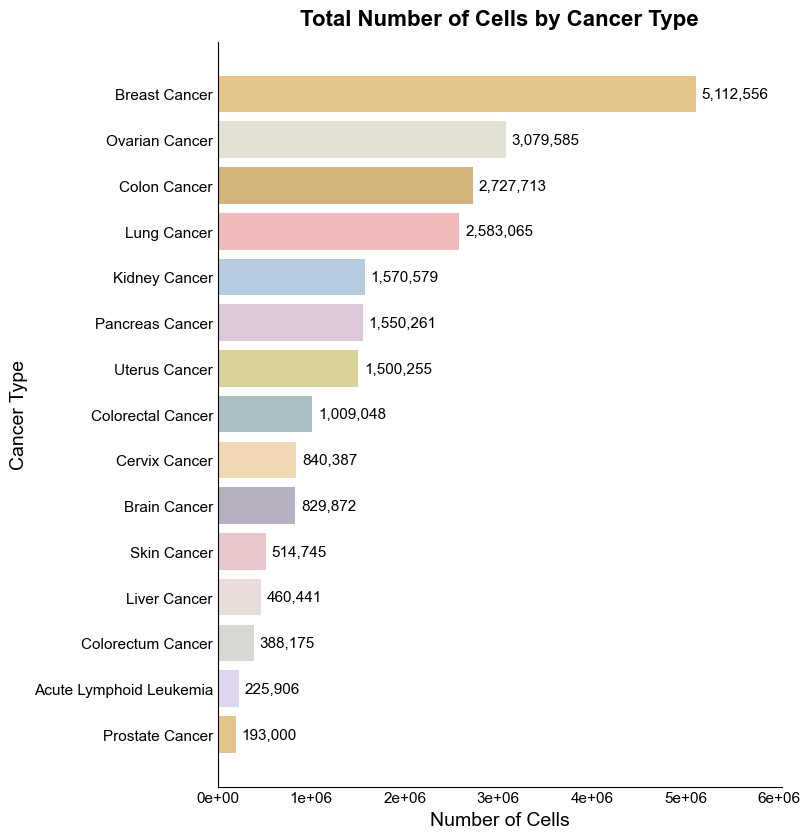

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Number of Cells by Cancer Type.pdf')

In [13]:
# Figure 1: total number of cells by cancer type.
cancer_type_totals = (
    plot_df.groupby('Cancer Type', as_index=False)['Number of Cells']
    .sum()
    .sort_values('Number of Cells', ascending=True)
)

fig_height = max(5.5, 0.5 * len(cancer_type_totals) + 1.0)
fig, ax = plt.subplots(figsize=(8.2, fig_height))
colors = cancer_type_totals['Cancer Type'].map(cancer_color_map).tolist()
bars = ax.barh(
    cancer_type_totals['Cancer Type'],
    cancer_type_totals['Number of Cells'],
    color=colors,
    edgecolor='none',
)

max_value = cancer_type_totals['Number of Cells'].max()
ax.set_xlim(0, max_value * 1.18)
for bar, value in zip(bars, cancer_type_totals['Number of Cells']):
    ax.text(
        value + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center',
        ha='left',
        fontsize=11,
        color='black',
    )

ax.set_xlabel('Number of Cells', fontsize=14)
ax.set_ylabel('Cancer Type', fontsize=14)
ax.set_title('Total Number of Cells by Cancer Type', fontsize=16, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(comma_formatter)
ax.tick_params(axis='both', labelsize=11, length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
fig.tight_layout()

cancer_type_pdf = FIGURES_DIR / 'Number of Cells by Cancer Type.pdf'
fig.savefig(cancer_type_pdf, format='pdf', bbox_inches='tight')
plt.show()

cancer_type_pdf


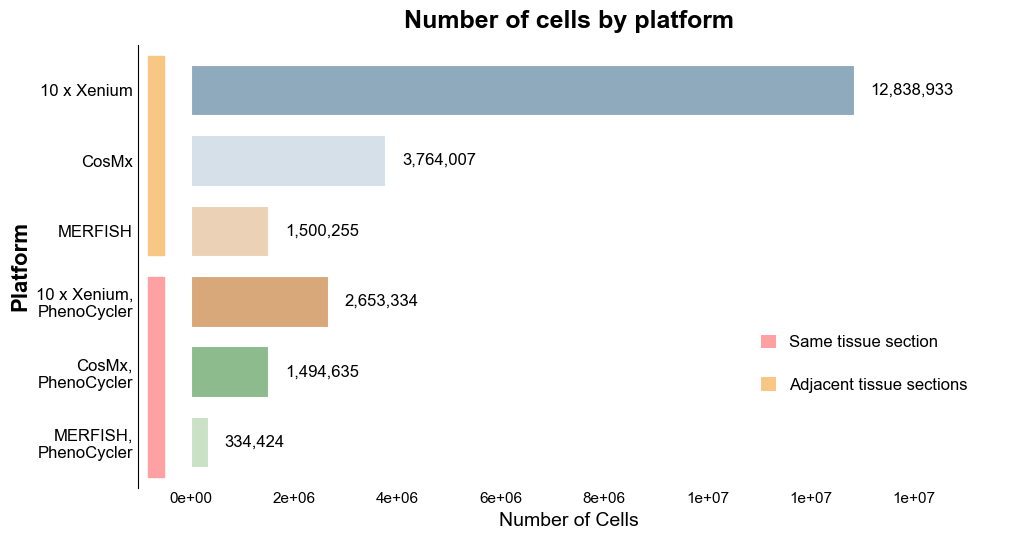

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Number of Cells by Platform.pdf')

In [14]:
# Figure 2: total number of cells by platform.
platform_totals = (
    plot_df.groupby(['Section Type', 'Platform'], as_index=False)['Number of Cells']
    .sum()
)
platform_totals['section_rank'] = platform_totals['Section Type'].map({
    'Same tissue section': 0,
    'Adjacent tissue sections': 1,
})
platform_totals = platform_totals.sort_values(
    ['section_rank', 'Number of Cells'],
    ascending=[True, False],
).reset_index(drop=True)

y = np.arange(len(platform_totals))
fig_height = max(5.5, 0.68 * len(platform_totals) + 1.0)
fig, ax = plt.subplots(figsize=(10.2, fig_height))
colors = platform_totals['Platform'].map(platform_color_map).tolist()
bars = ax.barh(
    y,
    platform_totals['Number of Cells'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.72,
)
ax.invert_yaxis()

max_value = platform_totals['Number of Cells'].max()
ax.set_xlim(-max_value * 0.08, max_value * 1.22)
for bar, value in zip(bars, platform_totals['Number of Cells']):
    ax.text(
        value + max_value * 0.025,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center',
        ha='left',
        fontsize=12,
        color='black',
    )

for section, section_data in platform_totals.groupby('Section Type', sort=False):
    y_min = section_data.index.min() - 0.35
    y_max = section_data.index.max() + 0.35
    ax.axvspan(
        -max_value * 0.065,
        -max_value * 0.04,
        ymin=(y_min + 0.5) / len(platform_totals),
        ymax=(y_max + 0.5) / len(platform_totals),
        color=section_color_map[section],
        clip_on=False,
    )

ax.set_yticks(y)
ax.set_yticklabels([str(x).replace('，', ',\n') for x in platform_totals['Platform']], fontsize=12)
ax.set_xlabel('Number of Cells', fontsize=14)
ax.set_ylabel('Platform', fontsize=16, fontweight='bold')
ax.set_title('Number of cells by platform', fontsize=18, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(comma_formatter)
ax.tick_params(axis='x', labelsize=11, length=0)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.grid(False)
ax.legend(
    handles=[Patch(facecolor=color, label=label) for label, color in section_color_map.items()],
    frameon=False,
    loc='center right',
    bbox_to_anchor=(0.98, 0.28),
    fontsize=12,
    handlelength=0.9,
    handleheight=0.9,
    labelspacing=1.6,
)
fig.tight_layout()

platform_bar_pdf = FIGURES_DIR / 'Number of Cells by Platform.pdf'
fig.savefig(platform_bar_pdf, format='pdf', bbox_inches='tight')
plt.show()

platform_bar_pdf


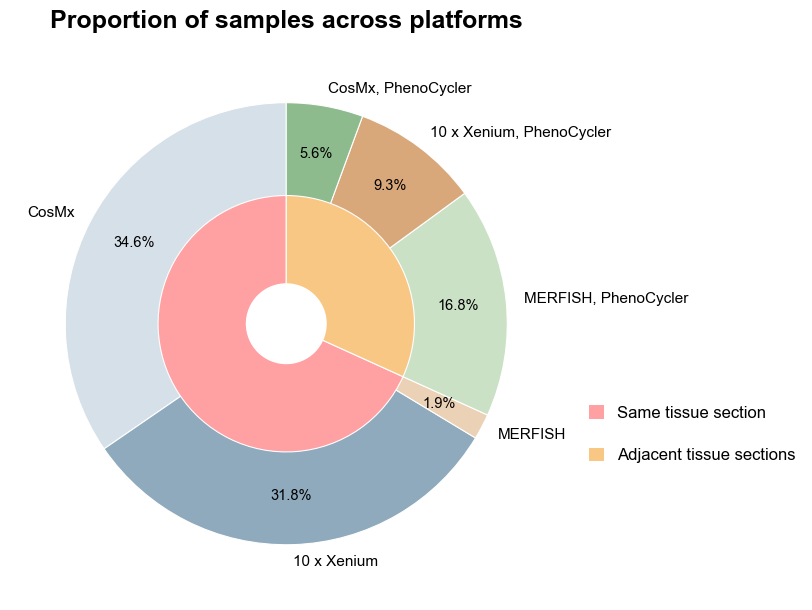

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Proportion of Samples across Platforms.pdf')

In [16]:
# Figure 3: proportion of samples across platforms.
platform_counts = (
    plot_df.groupby(['Section Type', 'Platform'])
    .size()
    .reset_index(name='n_samples')
)
platform_counts['section_rank'] = platform_counts['Section Type'].map({
    'Same tissue section': 0,
    'Adjacent tissue sections': 1,
})
platform_counts = platform_counts.sort_values(
    ['section_rank', 'n_samples'],
    ascending=[True, False],
).reset_index(drop=True)

section_counts = (
    platform_counts.groupby('Section Type', sort=False)['n_samples']
    .sum()
    .reindex(section_color_map.keys())
    .dropna()
)

fig, ax = plt.subplots(figsize=(9.8, 6.2))
outer_values = platform_counts['n_samples'].to_numpy()
outer_labels = [str(x).replace('，', ', ') for x in platform_counts['Platform']]
outer_colors = platform_counts['Platform'].map(platform_color_map).tolist()

outer_wedges, outer_texts, outer_autotexts = ax.pie(
    outer_values,
    labels=outer_labels,
    colors=outer_colors,
    startangle=90,
    counterclock=True,
    autopct=lambda pct: f'{pct:.1f}%',
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops=dict(width=0.50, edgecolor='white', linewidth=0.8),
    textprops=dict(color='black', fontsize=11),
)
for text in outer_autotexts:
    text.set_fontsize(10.5)

ax.pie(
    section_counts.to_numpy(),
    colors=[section_color_map[x] for x in section_counts.index],
    startangle=90,
    counterclock=True,
    radius=0.58,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=0.8),
)

centre_circle = plt.Circle((0, 0), 0.18, color='white')
ax.add_artist(centre_circle)
ax.set_title('Proportion of samples across platforms', fontsize=18, fontweight='bold', pad=14)
ax.legend(
    handles=[Patch(facecolor=color, label=label) for label, color in section_color_map.items()],
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.30),
    fontsize=12,
    handlelength=0.9,
    handleheight=0.9,
    labelspacing=1.6,
)
ax.set(aspect='equal')
fig.tight_layout()

platform_donut_pdf = FIGURES_DIR / 'Proportion of Samples across Platforms.pdf'
fig.savefig(platform_donut_pdf, format='pdf', bbox_inches='tight')
plt.show()

platform_donut_pdf


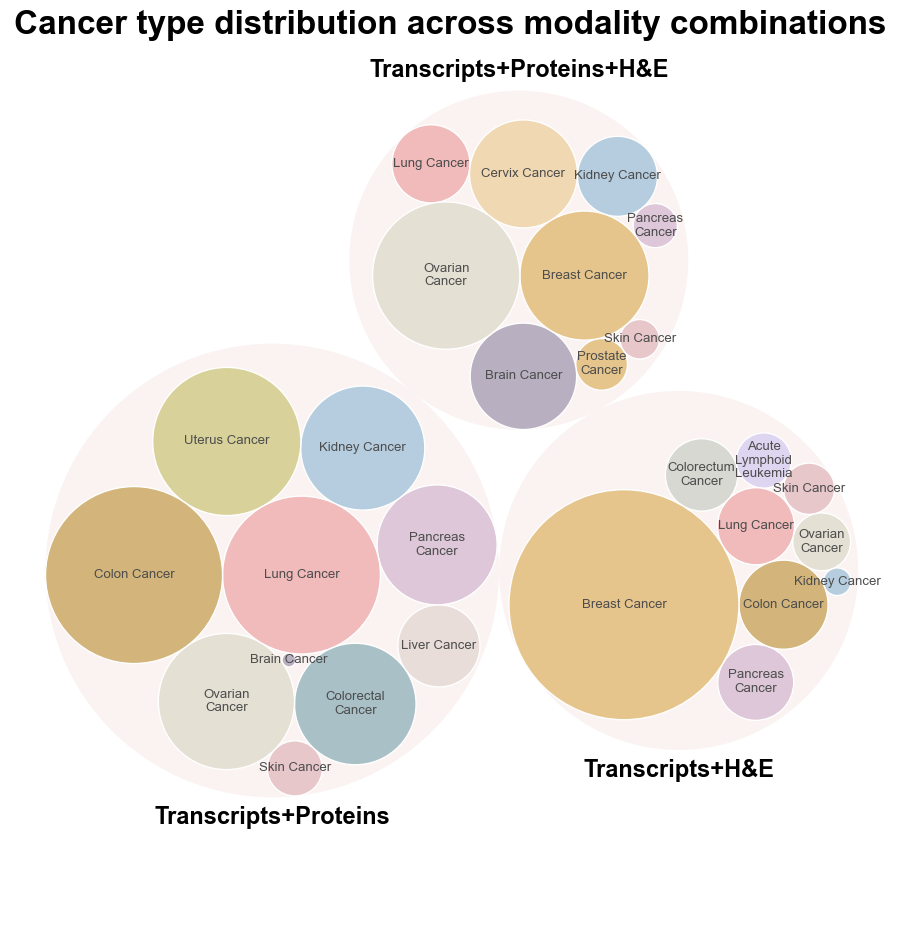

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Cancer Type Distribution across Modality Combinations.pdf')

In [ ]:
# Figure 4: cancer type distribution across modality combinations.

modality_label_map = {
    'RNA+protein': 'Transcripts+Proteins',
    'RNA+protein+HE': 'Transcripts+Proteins+H&E',
    'RNA+HE': 'Transcripts+H&E',
}
modality_order = ['RNA+protein', 'RNA+protein+HE', 'RNA+HE']

modality_cancer_totals = (
    plot_df.groupby(['Modality Type', 'Cancer Type'], as_index=False)['Number of Cells']
    .sum()
)
modality_cancer_totals['Modality Label'] = modality_cancer_totals['Modality Type'].map(modality_label_map)
modality_cancer_totals = modality_cancer_totals.dropna(subset=['Modality Label'])

circlify_data = []
for modality in modality_order:
    group = modality_cancer_totals[modality_cancer_totals['Modality Type'] == modality]
    if group.empty:
        continue
    group = group.sort_values('Number of Cells', ascending=False)
    children = [
        {
            'id': row['Cancer Type'],
            'datum': float(row['Number of Cells']),
        }
        for _, row in group.iterrows()
    ]
    circlify_data.append({
        'id': modality_label_map[modality],
        'datum': float(group['Number of Cells'].sum()),
        'children': children,
    })

circlify_data.sort(key=lambda item: item['datum'], reverse=True)
circles = circlify.circlify(
    circlify_data,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1),
)

fig, ax = plt.subplots(figsize=(11.2, 9.6), facecolor='white')
ax.set_aspect('equal')
ax.axis('off')

lim = max(abs(circle.x) + circle.r for circle in circles) * 1.08
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

# Parent circles
for circle in circles:
    if circle.level != 1:
        continue
    x, y, r = -circle.x, circle.y, circle.r
    ax.add_patch(Circle(
        (x, y),
        r,
        facecolor='#EED6D3',
        edgecolor='none',
        alpha=0.28,
        zorder=1,
    ))

# Child circles: cancer types, colored by the same Cancer Type palette used above.
for circle in circles:
    if circle.level != 2:
        continue
    x, y, r = -circle.x, circle.y, circle.r
    cancer_type = circle.ex['id']
    color = cancer_color_map.get(cancer_type, '#CFCFCF')
    ax.add_patch(Circle(
        (x, y),
        r,
        facecolor=color,
        edgecolor='white',
        linewidth=1.0,
        alpha=1,
        zorder=2,
    ))

    wrapped_label = '\n'.join(textwrap.wrap(cancer_type, width=13))
    fontsize = max(9.5, min(17, r * 30))
    ax.text(
        x,
        y,
        wrapped_label,
        ha='center',
        va='center',
        fontsize=fontsize,
        color='#4D4D4D',
        zorder=3,
    )

# Modality labels are placed just outside each parent circle.
for circle in circles:
    if circle.level != 1:
        continue
    x, y, r = -circle.x, circle.y, circle.r
    if y >= 0:
        label_y = y + r + lim * 0.02
        va = 'bottom'
    else:
        label_y = y - r - lim * 0.02
        va = 'top'
    ax.text(
        x,
        label_y,
        circle.ex['id'],
        ha='center',
        va=va,
        fontsize=17,
        fontweight='bold',
        color='black',
        zorder=4,
    )

ax.set_title(
    'Cancer type distribution across modality combinations',
    fontsize=24,
    fontweight='bold',
    pad=18,
)
fig.tight_layout()

modality_cancer_pdf = FIGURES_DIR / 'Cancer Type Distribution across Modality Combinations.pdf'
fig.savefig(modality_cancer_pdf, format='pdf', bbox_inches='tight')
plt.show()

modality_cancer_pdf


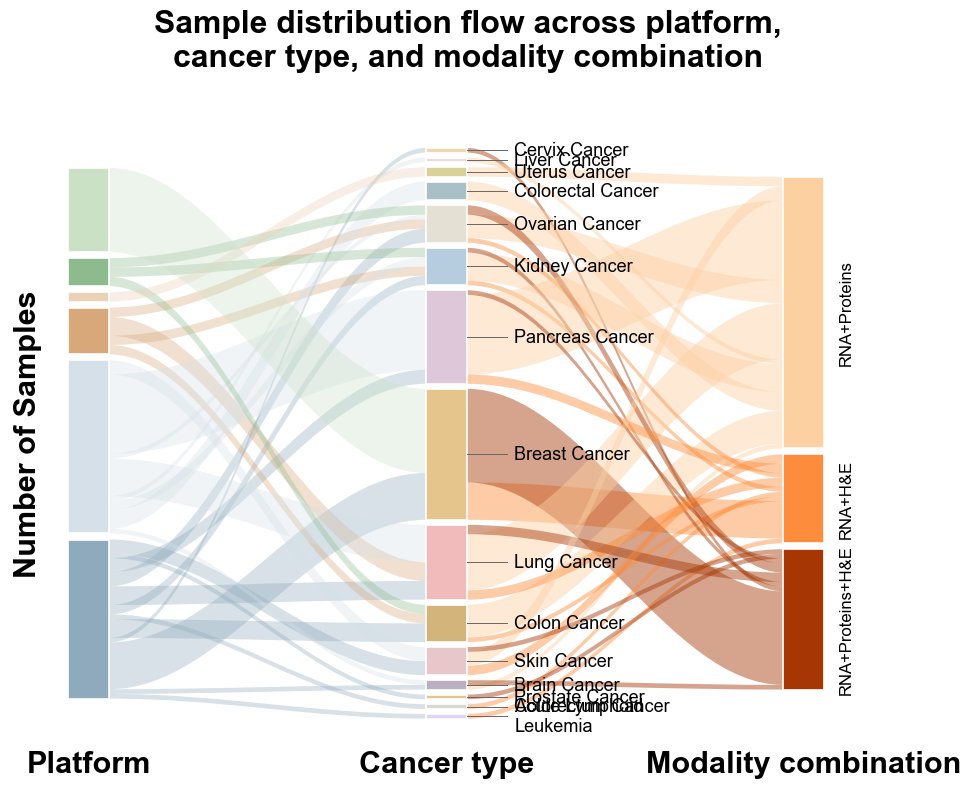

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Sample Distribution Flow across Platform Cancer Type and Modality Combination.pdf')

In [9]:
# Figure 5: sample distribution flow across platform, cancer type, and modality combination.
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.colors import to_rgba
import textwrap

flow_df = plot_df.dropna(subset=['Platform', 'Cancer Type', 'Modality Type']).copy()

platform_order = [p for p in platform_order_by_cells if p in flow_df['Platform'].unique()]
cancer_totals_for_flow = (
    flow_df.groupby('Cancer Type')
    .size()
    .sort_values(ascending=True)
)
cancer_sorted = cancer_totals_for_flow.index.tolist()
left_side = cancer_sorted[::2]
right_side = list(reversed(cancer_sorted[1::2]))
cancer_order_for_flow = left_side + right_side

preferred_modality_order = ['RNA+protein+HE', 'RNA+HE', 'RNA+protein']
observed_modalities = flow_df['Modality Type'].dropna().unique().tolist()
modality_order_for_flow = [m for m in preferred_modality_order if m in observed_modalities]
modality_order_for_flow += sorted([m for m in observed_modalities if m not in modality_order_for_flow])

modality_label_map = {
    'RNA+protein': 'RNA+Proteins',
    'RNA+protein+HE': 'RNA+Proteins+H&E',
    'RNA+HE': 'RNA+H&E',
}
modality_color_map = {
    'RNA+protein+HE': '#A63603',
    'RNA+HE': '#FD8D3C',
    'RNA+protein': '#FDD0A2',
}

flow_counts = (
    flow_df.groupby(['Platform', 'Cancer Type', 'Modality Type'])
    .size()
    .reset_index(name='n_samples')
)

platform_cancer = (
    flow_counts.groupby(['Platform', 'Cancer Type'], as_index=False)['n_samples']
    .sum()
)
cancer_modality = (
    flow_counts.groupby(['Cancer Type', 'Modality Type'], as_index=False)['n_samples']
    .sum()
)

platform_totals = flow_df['Platform'].value_counts().reindex(platform_order).fillna(0).to_dict()
cancer_totals = flow_df['Cancer Type'].value_counts().reindex(cancer_order_for_flow).fillna(0).to_dict()
modality_totals = flow_df['Modality Type'].value_counts().reindex(modality_order_for_flow).fillna(0).to_dict()

flow_height = float(len(flow_df))


def compute_intervals(labels, totals, gap):
    intervals = {}
    y = 0.0
    for label in labels:
        height = float(totals.get(label, 0.0))
        intervals[label] = [y, y + height]
        y += height + gap
    total_height = y - gap if labels else 0.0
    return intervals, total_height

def center_intervals(intervals, column_height, target_height):
    offset = (target_height - column_height) / 2.0
    return {label: [y0 + offset, y1 + offset] for label, (y0, y1) in intervals.items()}

platform_gap = flow_height * 0.012
cancer_gap = flow_height * 0.010
modality_gap = flow_height * 0.012

platform_intervals, platform_column_height = compute_intervals(platform_order, platform_totals, gap=platform_gap)
cancer_intervals, cancer_column_height = compute_intervals(cancer_order_for_flow, cancer_totals, gap=cancer_gap)
modality_intervals, modality_column_height = compute_intervals(modality_order_for_flow, modality_totals, gap=modality_gap)

plot_height = max(platform_column_height, cancer_column_height, modality_column_height, flow_height)
platform_intervals = center_intervals(platform_intervals, platform_column_height, plot_height)
cancer_intervals = center_intervals(cancer_intervals, cancer_column_height, plot_height)
modality_intervals = center_intervals(modality_intervals, modality_column_height, plot_height)

x_platform, x_cancer, x_modality = 0.0, 1.0, 2.0
bar_width = 0.115
curve_offset = 0.38

def draw_flow(ax, x0, x1, y0a, y0b, y1a, y1b, color, alpha=1, zorder=1):
    verts = [
        (x0 + bar_width / 2, y0a),
        (x0 + curve_offset, y0a),
        (x1 - curve_offset, y1a),
        (x1 - bar_width / 2, y1a),
        (x1 - bar_width / 2, y1b),
        (x1 - curve_offset, y1b),
        (x0 + curve_offset, y0b),
        (x0 + bar_width / 2, y0b),
        (x0 + bar_width / 2, y0a),
    ]
    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CLOSEPOLY,
    ]
    patch = PathPatch(
        MplPath(verts, codes),
        facecolor=to_rgba(color, alpha),
        edgecolor='none',
        zorder=zorder,
    )
    ax.add_patch(patch)

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_xlim(-0.22, 2.34)
ax.set_ylim(-plot_height * 0.08, plot_height * 1.10)
ax.axis('off')

platform_offsets = {label: platform_intervals[label][0] for label in platform_order}
cancer_in_offsets = {label: cancer_intervals[label][0] for label in cancer_order_for_flow}
cancer_out_offsets = {label: cancer_intervals[label][0] for label in cancer_order_for_flow}
modality_offsets = {label: modality_intervals[label][0] for label in modality_order_for_flow}

# Platform -> Cancer Type flows, colored by platform.
for _, row in platform_cancer.sort_values(['Platform', 'Cancer Type']).iterrows():
    platform = row['Platform']
    cancer = row['Cancer Type']
    value = float(row['n_samples'])
    if platform not in platform_offsets or cancer not in cancer_in_offsets:
        continue
    y0a = platform_offsets[platform]
    y0b = y0a + value
    y1a = cancer_in_offsets[cancer]
    y1b = y1a + value
    draw_flow(
        ax,
        x_platform,
        x_cancer,
        y0a,
        y0b,
        y1a,
        y1b,
        platform_color_map.get(platform, '#BDBDBD'),
        alpha=0.35,
        zorder=1,
    )
    platform_offsets[platform] = y0b
    cancer_in_offsets[cancer] = y1b

# Cancer Type -> Modality Combination flows, colored by modality.
# Each flow thickness equals n_samples in the same coordinate unit as the node heights.
for _, row in cancer_modality.sort_values(['Cancer Type', 'Modality Type']).iterrows():
    cancer = row['Cancer Type']
    modality = row['Modality Type']
    value = float(row['n_samples'])
    if cancer not in cancer_out_offsets or modality not in modality_offsets:
        continue
    y0a = cancer_out_offsets[cancer]
    y0b = y0a + value
    y1a = modality_offsets[modality]
    y1b = y1a + value
    draw_flow(
        ax,
        x_cancer,
        x_modality,
        y0a,
        y0b,
        y1a,
        y1b,
        modality_color_map.get(modality, '#BDBDBD'),
        alpha=0.45,
        zorder=2,
    )
    cancer_out_offsets[cancer] = y0b
    modality_offsets[modality] = y1b

# Draw strata on top of the flows.
for platform in platform_order:
    y0, y1 = platform_intervals[platform]
    ax.add_patch(Rectangle(
        (x_platform - bar_width / 2, y0),
        bar_width,
        y1 - y0,
        facecolor=platform_color_map.get(platform, '#BDBDBD'),
        edgecolor='white',
        linewidth=1.2,
        zorder=4,
    ))

for cancer in cancer_order_for_flow:
    y0, y1 = cancer_intervals[cancer]
    ax.add_patch(Rectangle(
        (x_cancer - bar_width / 2, y0),
        bar_width,
        y1 - y0,
        facecolor=cancer_color_map.get(cancer, '#D9D9D9'),
        edgecolor='white',
        linewidth=1.2,
        zorder=4,
    ))
    y_mid = (y0 + y1) / 2
    label = '\n'.join(textwrap.wrap(cancer, width=18))
    ax.plot([x_cancer + bar_width / 2, x_cancer + 0.17], [y_mid, y_mid], color='#666666', linewidth=0.7, zorder=5)
    ax.text(x_cancer + 0.19, y_mid, label, ha='left', va='center', fontsize=13, color='black', zorder=5)

for modality in modality_order_for_flow:
    y0, y1 = modality_intervals[modality]
    ax.add_patch(Rectangle(
        (x_modality - bar_width / 2, y0),
        bar_width,
        y1 - y0,
        facecolor=modality_color_map.get(modality, '#BDBDBD'),
        edgecolor='white',
        linewidth=1.2,
        zorder=4,
    ))
    ax.text(
        x_modality + bar_width / 2 + 0.04,
        (y0 + y1) / 2,
        modality_label_map.get(modality, modality),
        ha='left',
        va='center',
        rotation=90,
        fontsize=12,
        color='black',
        zorder=5,
    )

ax.text(x_platform, -plot_height * 0.055, 'Platform', ha='center', va='top', fontsize=22, fontweight='bold')
ax.text(x_cancer, -plot_height * 0.055, 'Cancer type', ha='center', va='top', fontsize=22, fontweight='bold')
ax.text(x_modality, -plot_height * 0.055, 'Modality combination', ha='center', va='top', fontsize=22, fontweight='bold')
ax.text(-0.17, plot_height / 2, 'Number of Samples', rotation=90, ha='center', va='center', fontsize=22, fontweight='bold')
ax.set_title(
    'Sample distribution flow across platform,\ncancer type, and modality combination',
    fontsize=23,
    fontweight='bold',
    pad=18,
)

fig.tight_layout()
flow_pdf = FIGURES_DIR / 'Sample Distribution Flow across Platform Cancer Type and Modality Combination.pdf'
fig.savefig(flow_pdf, format='pdf', bbox_inches='tight')
plt.show()

flow_pdf



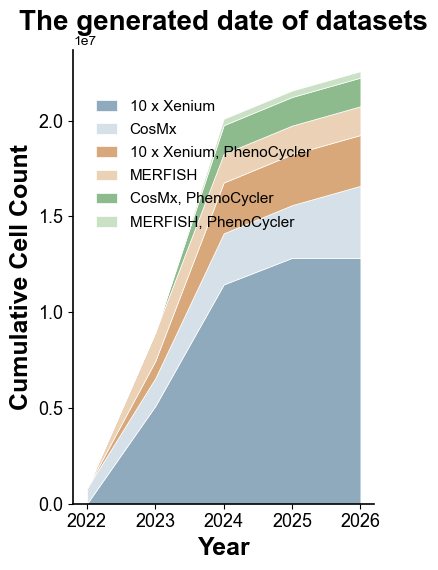

PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/The Generated Date of Datasets.pdf')

In [19]:
# Figure 6: generated date of datasets, shown as cumulative cell counts by platform.
year_col = 'Publication Year'
area_df = plot_df.dropna(subset=[year_col, 'Platform', 'Number of Cells']).copy()
area_df[year_col] = pd.to_numeric(area_df[year_col], errors='coerce')
area_df = area_df.dropna(subset=[year_col])
area_df[year_col] = area_df[year_col].astype(int)

platform_year_cells = (
    area_df.groupby([year_col, 'Platform'], as_index=False)['Number of Cells']
    .sum()
)
platform_year_pivot = (
    platform_year_cells
    .pivot(index=year_col, columns='Platform', values='Number of Cells')
    .fillna(0)
    .sort_index()
)

all_years = np.arange(platform_year_pivot.index.min(), platform_year_pivot.index.max() + 1)
platform_year_pivot = platform_year_pivot.reindex(all_years, fill_value=0)
platform_year_cumsum = platform_year_pivot.cumsum()

platform_order_for_area = [p for p in platform_order_by_cells if p in platform_year_cumsum.columns]
years = platform_year_cumsum.index.to_numpy()
data_for_stack = [platform_year_cumsum[p].to_numpy() for p in platform_order_for_area]
colors = [platform_color_map[p] for p in platform_order_for_area]

fig, ax = plt.subplots(figsize=(4, 5.8), facecolor='white')
ax.stackplot(
    years,
    *data_for_stack,
    labels=[str(p).replace('，', ', ') for p in platform_order_for_area],
    colors=colors,
    alpha=1,
    edgecolor='white',
    linewidth=0.5,
)

ax.set_xlabel('Year', fontsize=18, fontweight='bold')
ax.set_ylabel('Cumulative Cell Count', fontsize=18, fontweight='bold')
ax.set_title('The generated date of datasets', fontsize=20, fontweight='bold', pad=14)
ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years], fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.03, 0.92),
    frameon=False,
    fontsize=11,
    handlelength=1.4,
    labelspacing=0.6,
)

fig.tight_layout()
area_pdf = FIGURES_DIR / 'The Generated Date of Datasets.pdf'
fig.savefig(area_pdf, format='pdf', bbox_inches='tight')
plt.show()

area_pdf


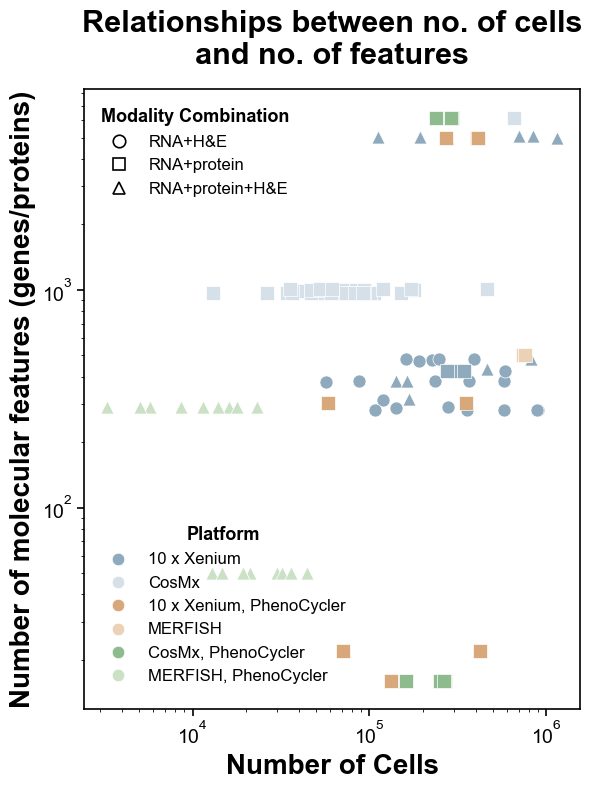

Feature cache: /mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/molecular_features_cache.csv
Features cached: 107 / 107 samples
Plotted samples with valid cells and features: 107 / 107 samples


PosixPath('/mnt/T40/lzh/0.Code/1. Database/2. Downstream/Data_statistics/figures/Relationships between Number of Cells and Number of Features.pdf')

In [7]:
feature_cache_path = DATA_STATISTICS_DIR / 'molecular_features_cache.csv'

# Prepare source metadata
feature_source_df = df.copy()
feature_source_df['h5ad_path'] = feature_source_df['basic_csv_path'].map(
    lambda x: str(Path(str(x)).parent / 'Download.h5ad')
)
feature_source_df['Number of Cells'] = pd.to_numeric(feature_source_df['Number of Cells'], errors='coerce')

cache_columns = [
    'Sample ID', 'h5ad_path', 'Platform', 'Modality Type',
    'Number of Cells', 'Number_of_Features'
]

required_records = (
    feature_source_df[['Sample ID', 'h5ad_path', 'Platform', 'Modality Type', 'Number of Cells']]
    .drop_duplicates(subset=['Sample ID', 'h5ad_path'], keep='last')
)

# Load existing feature cache
if feature_cache_path.exists():
    old_feature_cache = pd.read_csv(feature_cache_path)

    for col in ['Sample ID', 'h5ad_path', 'Number_of_Features']:
        if col not in old_feature_cache.columns:
            old_feature_cache[col] = pd.NA

    old_feature_cache = (
        old_feature_cache[['Sample ID', 'h5ad_path', 'Number_of_Features']]
        .drop_duplicates(subset=['Sample ID', 'h5ad_path'], keep='last')
    )
else:
    old_feature_cache = pd.DataFrame(columns=['Sample ID', 'h5ad_path', 'Number_of_Features'])

feature_cache = required_records.merge(old_feature_cache, on=['Sample ID', 'h5ad_path'], how='left')
feature_cache['Number_of_Features'] = pd.to_numeric(feature_cache['Number_of_Features'], errors='coerce')

# Count features only for missing samples
missing_keys = feature_cache[feature_cache['Number_of_Features'].isna()][['Sample ID', 'h5ad_path']]

new_feature_records = []
failed_feature_files = []

for _, row in missing_keys.iterrows():
    h5ad_path = Path(row['h5ad_path'])

    try:
        with h5py.File(h5ad_path, 'r') as h5:
            if 'var' in h5 and '_index' in h5['var']:
                n_features = int(h5['var']['_index'].shape[0])
            elif 'var' in h5 and len(h5['var'].keys()) > 0:
                n_features = int(next(iter(h5['var'].values())).shape[0])
            else:
                raise KeyError('No var group found in h5ad file')

        new_feature_records.append({
            'Sample ID': row['Sample ID'],
            'h5ad_path': str(h5ad_path),
            'Number_of_Features': n_features,
        })

    except Exception as exc:
        failed_feature_files.append((row['Sample ID'], str(h5ad_path), str(exc)))

# Update cache with newly counted features
if new_feature_records:
    new_feature_df = pd.DataFrame(new_feature_records)
    feature_cache = feature_cache.drop(columns=['Number_of_Features'])
    feature_cache = feature_cache.merge(
        pd.concat([old_feature_cache, new_feature_df], ignore_index=True)
        .drop_duplicates(subset=['Sample ID', 'h5ad_path'], keep='last'),
        on=['Sample ID', 'h5ad_path'],
        how='left'
    )

feature_cache['Number of Cells'] = pd.to_numeric(feature_cache['Number of Cells'], errors='coerce')
feature_cache['Number_of_Features'] = pd.to_numeric(feature_cache['Number_of_Features'], errors='coerce')
feature_cache = feature_cache[cache_columns]
feature_cache.to_csv(feature_cache_path, index=False)

# Use cache for plotting
feature_df = feature_cache.copy()
feature_df = feature_df.dropna(
    subset=['Platform', 'Modality Type', 'Number of Cells', 'Number_of_Features']
)
feature_df = feature_df[
    (feature_df['Number of Cells'] > 0) &
    (feature_df['Number_of_Features'] > 0)
]

modality_marker_map = {
    'RNA+HE': 'o',
    'RNA+protein': 's',
    'RNA+protein+HE': '^',
}

modality_label_map = {
    'RNA+HE': 'RNA+H&E',
    'RNA+protein': 'RNA+protein',
    'RNA+protein+HE': 'RNA+protein+H&E',
}

modality_order_for_scatter = [m for m in modality_marker_map if m in feature_df['Modality Type'].unique()]
platform_order_for_scatter = [p for p in platform_order_by_cells if p in feature_df['Platform'].unique()]

# Plot scatter
fig, ax = plt.subplots(figsize=(6, 8), facecolor='white')

for platform in platform_order_for_scatter:
    for modality in modality_order_for_scatter:
        subset = feature_df[
            (feature_df['Platform'] == platform) &
            (feature_df['Modality Type'] == modality)
        ]

        if subset.empty:
            continue

        ax.scatter(
            subset['Number of Cells'],
            subset['Number_of_Features'],
            marker=modality_marker_map[modality],
            s=88,
            color=platform_color_map.get(platform, '#BDBDBD'),
            alpha=1,
            edgecolors='white',
            linewidths=0.5,
            zorder=3,
        )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Cells', fontsize=20, fontweight='bold')
ax.set_ylabel('Number of molecular features (genes/proteins)', fontsize=20, fontweight='bold')
ax.set_title('Relationships between no. of cells\nand no. of features', fontsize=22, fontweight='bold', pad=18)

ax.tick_params(axis='both', labelsize=14, width=1.2, length=5)
ax.grid(False)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')

# Add legends
modality_handles = [
    Line2D(
        [0], [0],
        marker=modality_marker_map[modality],
        linestyle='None',
        color='black',
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=1.2,
        markersize=9,
        label=modality_label_map.get(modality, modality),
    )
    for modality in modality_order_for_scatter
]

platform_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        color='none',
        markerfacecolor=platform_color_map.get(platform, '#BDBDBD'),
        markeredgecolor='white',
        markeredgewidth=0.5,
        markersize=9,
        label=str(platform).replace('，', ', '),
    )
    for platform in platform_order_for_scatter
]

legend_modality = ax.legend(
    handles=modality_handles,
    title='Modality Combination',
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98),
    frameon=False,
    fontsize=12,
    title_fontsize=13,
    borderaxespad=0.0,
)
legend_modality.get_title().set_fontweight('bold')
ax.add_artist(legend_modality)

legend_platform = ax.legend(
    handles=platform_handles,
    title='Platform',
    loc='lower left',
    bbox_to_anchor=(0.02, 0.03),
    frameon=False,
    fontsize=12,
    title_fontsize=13,
    borderaxespad=0.0,
)
legend_platform.get_title().set_fontweight('bold')

# Save figure and report status
fig.tight_layout()

features_scatter_pdf = FIGURES_DIR / 'Relationships between Number of Cells and Number of Features.pdf'
fig.savefig(features_scatter_pdf, format='pdf', bbox_inches='tight')

plt.show()

print(f'Feature cache: {feature_cache_path}')
print(f'Features cached: {feature_cache["Number_of_Features"].notna().sum()} / {len(feature_cache)} samples')
print(f'Plotted samples with valid cells and features: {len(feature_df)} / {len(df)} samples')

if failed_feature_files:
    print('Failed files:')
    for sample_id, h5ad_path, error in failed_feature_files[:10]:
        print(f'  {sample_id}: {h5ad_path} | {error}')

features_scatter_pdf